## Notebook de tests à réutiliser et adapter pour observer les processus de débruitage et l'interpolation dans l'espace latent d'un modèle (contient des cellules pour modèle non-conditionnel et modèle conditionnel)

Génération en cours...


  0%|          | 0/1000 [00:00<?, ?it/s]

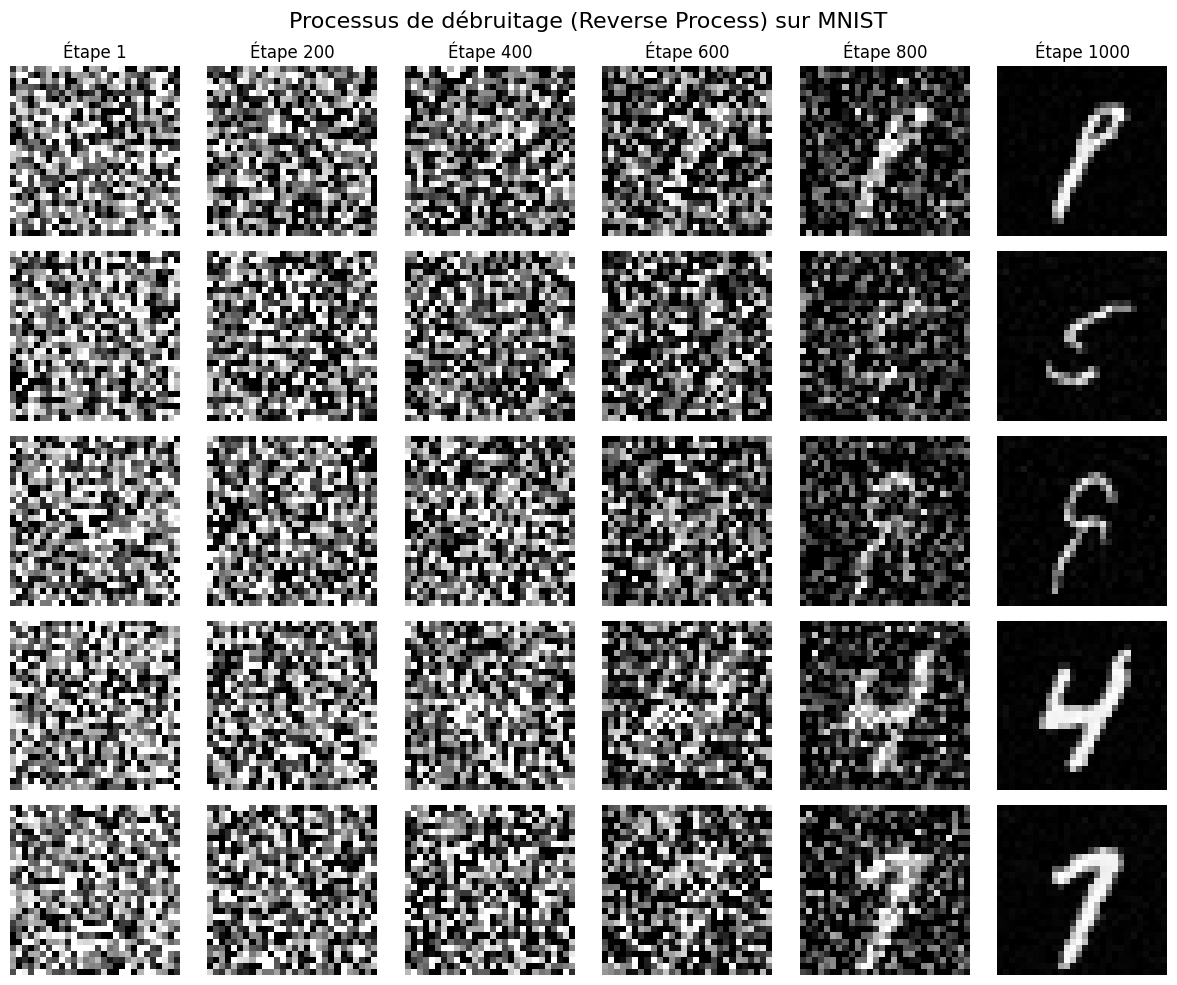

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm.auto import tqdm

from ddpm_mnist import BetterUNet, ImageNoiseScheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Charger le modèle entraîné
model = BetterUNet(base_ch=64).to(device)
model.load_state_dict(torch.load("exps/mnist_unet_opti/ema_model.pth"))
model.eval()

# 2. Paramètres de génération
num_timesteps = 1000
plot_step = 200 # On sauvegardera l'image tous les 200 pas
eval_batch_size = 5 # On va générer 5 chiffres différents

noise_scheduler = ImageNoiseScheduler(num_timesteps=num_timesteps)

# On part de bruit pur : (Batch, 1 canal, 28 px, 28 px)
sample = torch.randn(eval_batch_size, 1, 28, 28).to(device)
timesteps = list(range(num_timesteps))[::-1]

# Pour stocker les étapes visuelles
samples_history = []
steps_history = []

print("Génération en cours...")
for i, t in enumerate(tqdm(timesteps)):
    t_tensor = torch.full((eval_batch_size,), t, device=device, dtype=torch.long)
    with torch.no_grad():
        residual = model(sample, t_tensor)

    sample = noise_scheduler.step(residual, t, sample)

    # On sauvegarde l'état tous les `plot_step` ou à la toute première étape
    if (i + 1) % plot_step == 0 or i == 0:
        samples_history.append(sample.cpu().numpy())
        steps_history.append(i + 1)

# 3. Affichage : Une grille avec les étapes en colonnes et les chiffres en lignes
num_cols = len(samples_history)
num_rows = eval_batch_size

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
plt.suptitle("Processus de débruitage (Reverse Process) sur MNIST", fontsize=16)

for row in range(num_rows):
    for col in range(num_cols):
        ax = axes[row, col]
        # On extrait l'image (28x28) du tableau (Batch, Canal, H, W)
        img = samples_history[col][row, 0, :, :]
        ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
        if row == 0:
            ax.set_title(f"Étape {steps_history[col]}")

plt.tight_layout()
plt.show()

Débruitage de l'interpolation en cours...


  0%|          | 0/1000 [00:00<?, ?it/s]

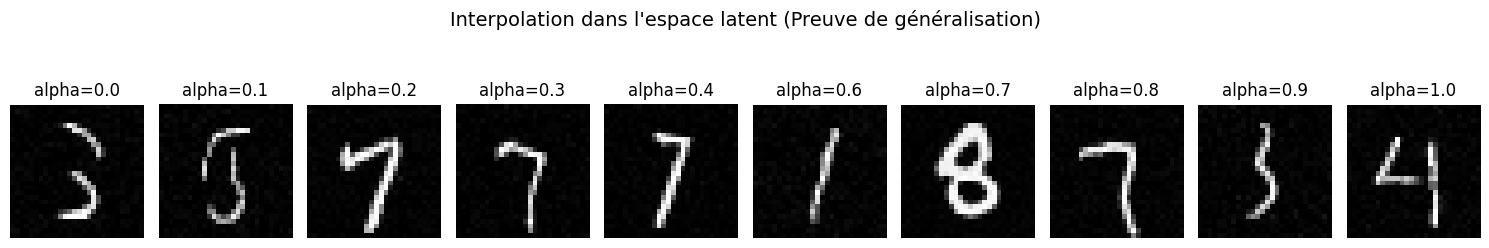

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm.auto import tqdm

from ddpm_mnist import BetterUNet, ImageNoiseScheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Charger le modèle EMA
model = BetterUNet(base_ch=64).to(device)
model.load_state_dict(torch.load("exps/mnist_unet_opti/ema_model.pth"))
model.eval()

noise_scheduler = ImageNoiseScheduler(num_timesteps=1000)

def slerp(val, low, high):
    """Interpolation Linéaire Sphérique (idéale pour des distributions Gaussiennes)"""
    omega = torch.acos((low/torch.norm(low) * high/torch.norm(high)).sum())
    so = torch.sin(omega)
    if so == 0:
        return (1.0-val) * low + val * high # Fallback linéaire
    return torch.sin((1.0-val)*omega) / so * low + torch.sin(val*omega) / so * high

# 2. Générer deux bruits purs totalement différents (Point A et Point B)
noise_A = torch.randn(1, 1, 28, 28).to(device)
noise_B = torch.randn(1, 1, 28, 28).to(device)

# 3. Créer 10 étapes d'interpolation entre A et B
num_steps = 10
interpolated_noises = []
for alpha in np.linspace(0, 1, num_steps):
    # On mélange les deux bruits
    mixed_noise = slerp(alpha, noise_A, noise_B)
    interpolated_noises.append(mixed_noise)

# On concatène tout dans un seul batch pour aller plus vite
batch_noise = torch.cat(interpolated_noises, dim=0)

# 4. Processus de débruitage inverse
timesteps = list(range(1000))[::-1]
sample = batch_noise

print("Débruitage de l'interpolation en cours...")
for t in tqdm(timesteps):
    t_tensor = torch.full((num_steps,), t, device=device, dtype=torch.long)
    with torch.no_grad():
        residual = model(sample, t_tensor)
    sample = noise_scheduler.step(residual, t, sample)

# 5. Affichage du résultat
fig, axes = plt.subplots(1, num_steps, figsize=(15, 3))
plt.suptitle("Interpolation dans l'espace latent (Preuve de généralisation)", fontsize=14)

samples_np = sample.cpu().numpy()
for i in range(num_steps):
    axes[i].imshow(samples_np[i, 0], cmap="gray", vmin=-1, vmax=1)
    axes[i].axis("off")
    axes[i].set_title(f"alpha={np.linspace(0, 1, num_steps)[i]:.1f}")

plt.tight_layout()
plt.show()

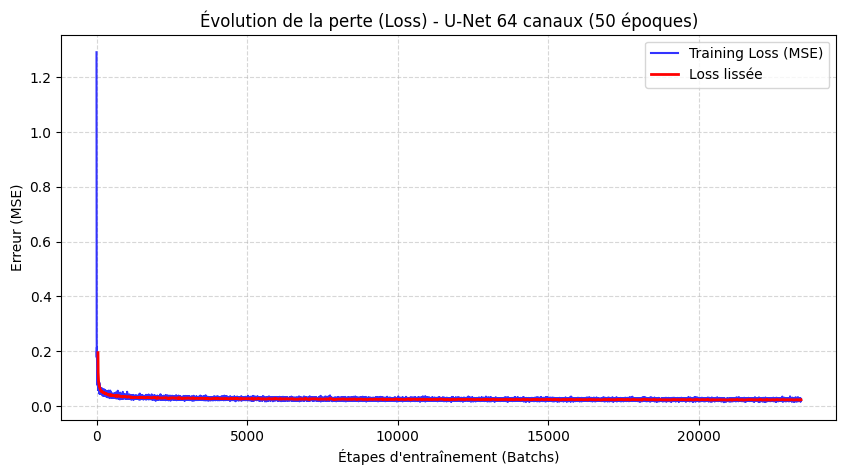

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

loss_path = "exps/mnist_unet_opti/loss.npy"

losses = np.load(loss_path)

plt.figure(figsize=(10, 5))
plt.plot(losses, label="Training Loss (MSE)", color="blue", alpha=0.8)

# On lisse un peu la courbe pour y voir plus clair (moyenne mobile)
# car la loss par batch est souvent très "bruitée"
window_size = 50
smoothed_losses = np.convolve(losses, np.ones(window_size)/window_size, mode='valid')
plt.plot(np.arange(window_size-1, len(losses)), smoothed_losses,
         color="red", linewidth=2, label="Loss lissée")

plt.title("Évolution de la perte (Loss) - U-Net 64 canaux (50 époques)")
plt.xlabel("Étapes d'entraînement (Batchs)")
plt.ylabel("Erreur (MSE)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Génération conditionnelle en cours...


  0%|          | 0/1000 [00:00<?, ?it/s]

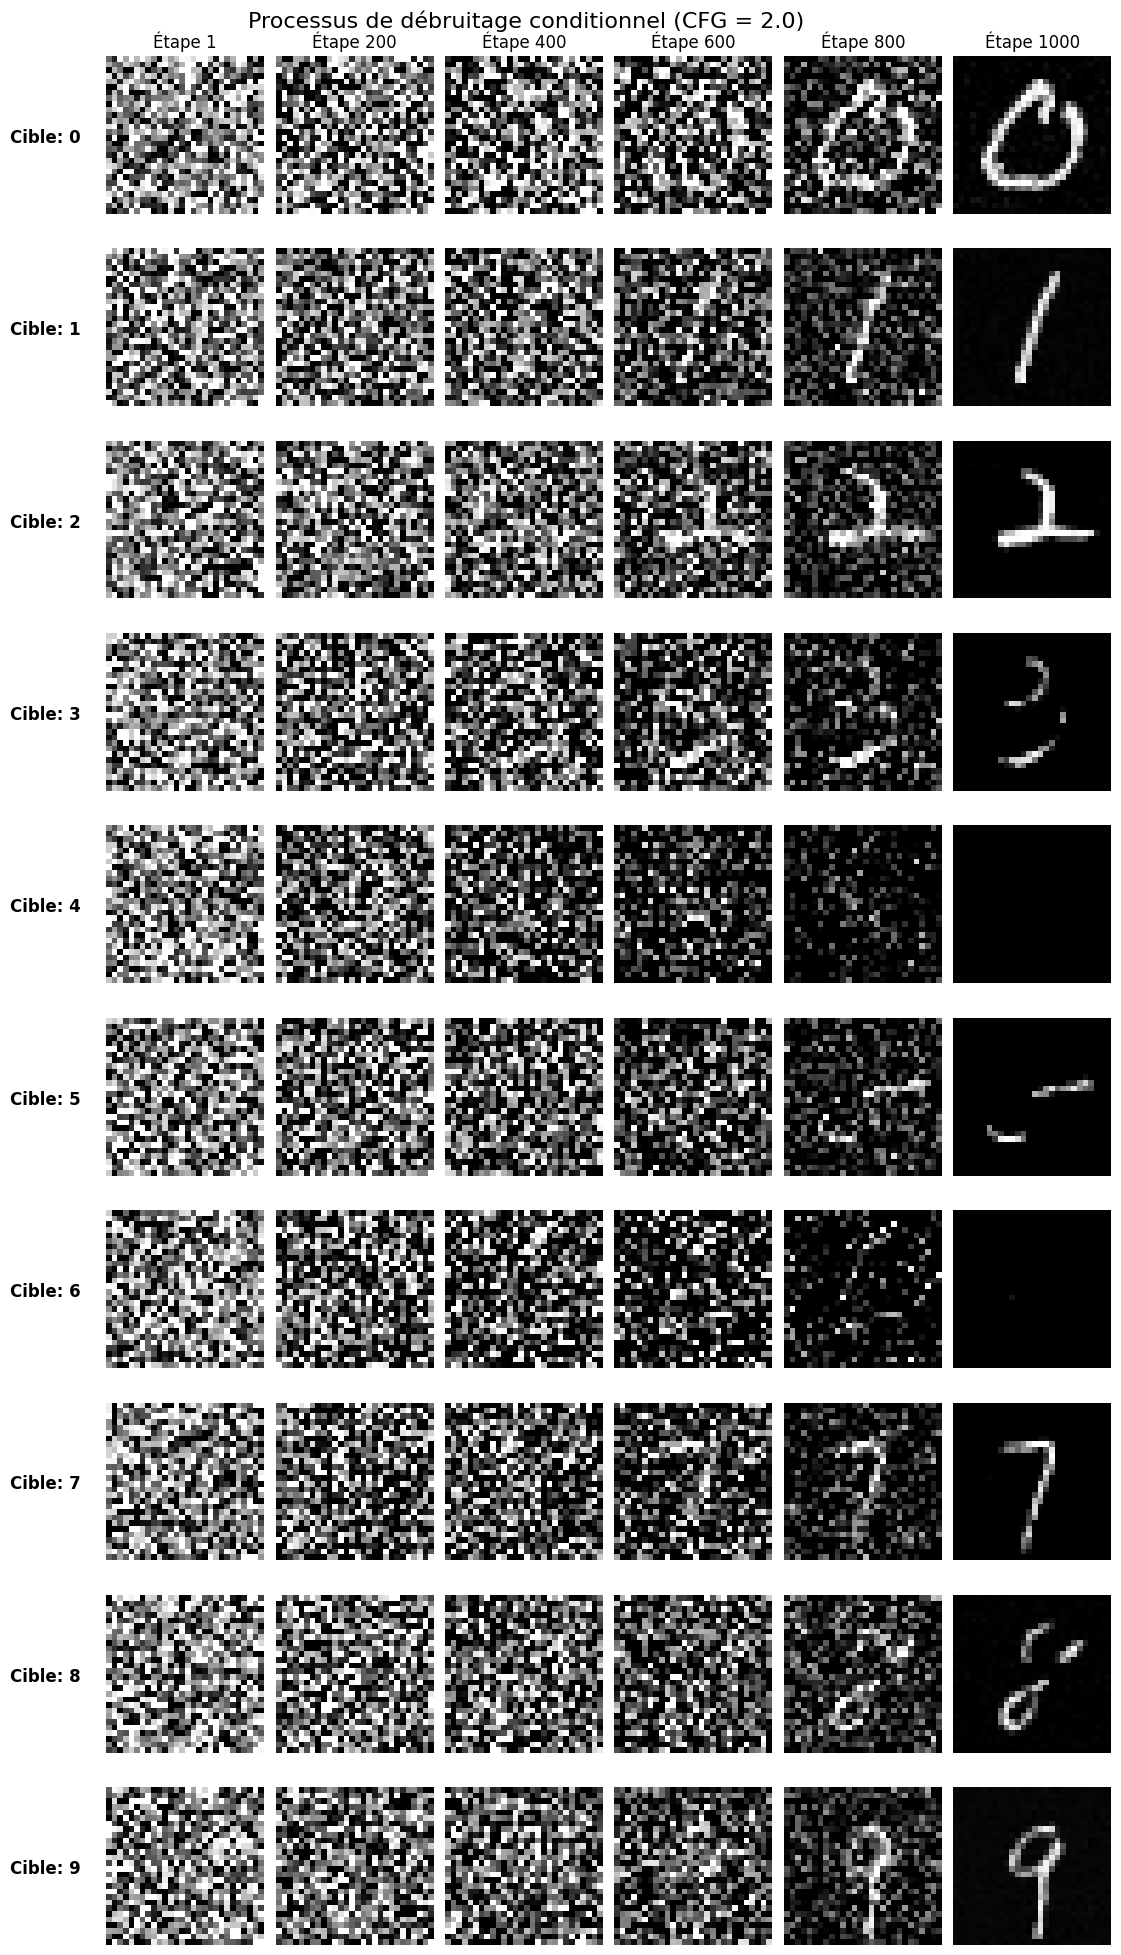

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm.auto import tqdm

from ddpm_mnist_conditionnal import ConditionalUNet, ImageNoiseScheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Charger le modèle entraîné
model = ConditionalUNet(base_ch=64, num_classes=10).to(device)
model.load_state_dict(torch.load("exps/mnist_cond_run1/ema_model.pth"))
model.eval()

# 2. Paramètres de génération
num_timesteps = 1000
plot_step = 200 # On sauvegardera l'image tous les 200 pas
eval_batch_size = 10 # On va générer 5 chiffres différents

# --- NOUVEAUX PARAMÈTRES POUR LE CONDITIONNEMENT ---
guidance_scale = 2.0
NULL_CLASS = 10
# Choix des chiffres à générer pour cet exemple
y_target = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], device=device, dtype=torch.long)
y_null = torch.full((eval_batch_size,), NULL_CLASS, device=device, dtype=torch.long)
# ---------------------------------------------------

noise_scheduler = ImageNoiseScheduler(num_timesteps=num_timesteps)

# On part de bruit pur : (Batch, 1 canal, 28 px, 28 px)
sample = torch.randn(eval_batch_size, 1, 28, 28).to(device)
timesteps = list(range(num_timesteps))[::-1]

# Pour stocker les étapes visuelles
samples_history = []
steps_history = []

print("Génération conditionnelle en cours...")
for i, t in enumerate(tqdm(timesteps)):
    t_tensor = torch.full((eval_batch_size,), t, device=device, dtype=torch.long)

    with torch.no_grad():
        # --- CLASSIFIER-FREE GUIDANCE ---
        # Prédiction avec la classe cible
        noise_cond = model(sample, t_tensor, y_target)
        # Prédiction inconditionnelle (classe "nulle")
        noise_uncond = model(sample, t_tensor, y_null)

        # Extrapolation CFG
        residual = noise_uncond + guidance_scale * (noise_cond - noise_uncond)
        # --------------------------------

    sample = noise_scheduler.step(residual, t, sample)

    # On sauvegarde l'état tous les `plot_step` ou à la toute première étape
    if (i + 1) % plot_step == 0 or i == 0:
        samples_history.append(sample.cpu().numpy())
        steps_history.append(i + 1)

# 3. Affichage : Une grille avec les étapes en colonnes et les chiffres en lignes
num_cols = len(samples_history)
num_rows = eval_batch_size

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
plt.suptitle(f"Processus de débruitage conditionnel (CFG = {guidance_scale})", fontsize=16)

for row in range(num_rows):
    for col in range(num_cols):
        ax = axes[row, col]
        # On extrait l'image (28x28) du tableau (Batch, Canal, H, W)
        img = samples_history[col][row, 0, :, :]
        ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")

        # Ajout du titre de l'étape pour la première ligne
        if row == 0:
            ax.set_title(f"Étape {steps_history[col]}")
        # Ajout du label cible pour la première colonne
        if col == 0:
            ax.text(-5, 14, f"Cible: {y_target[row].item()}",
                    va='center', ha='right', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(left=0.15) # On laisse un peu d'espace à gauche pour le texte
plt.show()

Débruitage de l'interpolation en cours (Cible : 8)...


  0%|          | 0/1000 [00:00<?, ?it/s]

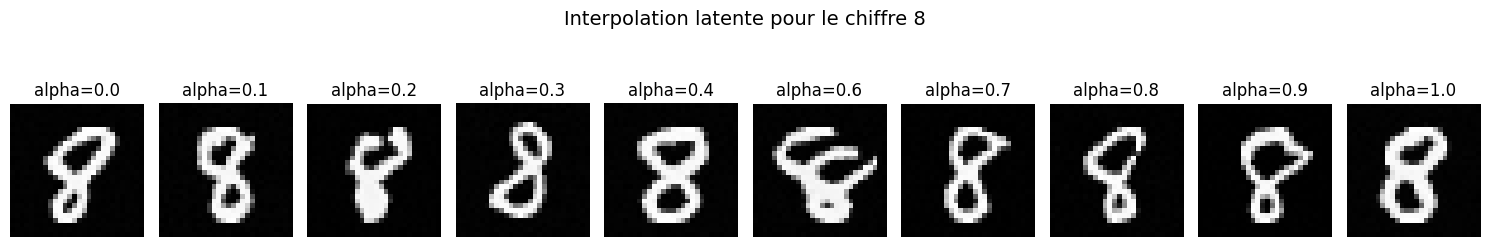

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm.auto import tqdm

from ddpm_mnist_conditionnal import ConditionalUNet, ImageNoiseScheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Charger le modèle EMA conditionnel
model = ConditionalUNet(base_ch=64, num_classes=10).to(device)
model.load_state_dict(torch.load("exps/mnist_cond_run2/ema_model.pth"))
model.eval()

noise_scheduler = ImageNoiseScheduler(num_timesteps=1000)

def slerp(val, low, high):
    """Interpolation Linéaire Sphérique (idéale pour des distributions Gaussiennes)"""
    omega = torch.acos((low/torch.norm(low) * high/torch.norm(high)).sum())
    so = torch.sin(omega)
    if so == 0:
        return (1.0-val) * low + val * high # Fallback linéaire
    return torch.sin((1.0-val)*omega) / so * low + torch.sin(val*omega) / so * high

# 2. Générer deux bruits purs totalement différents (Point A et Point B)
noise_A = torch.randn(1, 1, 28, 28).to(device)
noise_B = torch.randn(1, 1, 28, 28).to(device)

# 3. Créer 10 étapes d'interpolation entre A et B
num_steps = 10
interpolated_noises = []
for alpha in np.linspace(0, 1, num_steps):
    # On mélange les deux bruits
    mixed_noise = slerp(alpha, noise_A, noise_B)
    interpolated_noises.append(mixed_noise)

# On concatène tout dans un seul batch pour aller plus vite (10, 1, 28, 28)
batch_noise = torch.cat(interpolated_noises, dim=0)

# --- NOUVEAUX PARAMÈTRES DE CONDITIONNEMENT ---
guidance_scale = 2.0
NULL_CLASS = 10
target_digit = 8 # On choisit de générer des variations du chiffre 8

# On prépare les tenseurs de labels pour le batch entier
y_target = torch.full((num_steps,), target_digit, device=device, dtype=torch.long)
y_null = torch.full((num_steps,), NULL_CLASS, device=device, dtype=torch.long)
# ----------------------------------------------

# 4. Processus de débruitage inverse avec CFG
timesteps = list(range(1000))[::-1]
sample = batch_noise

print(f"Débruitage de l'interpolation en cours (Cible : {target_digit})...")
for t in tqdm(timesteps):
    t_tensor = torch.full((num_steps,), t, device=device, dtype=torch.long)

    with torch.no_grad():
        # Passe conditionnelle
        noise_cond = model(sample, t_tensor, y_target)
        # Passe inconditionnelle
        noise_uncond = model(sample, t_tensor, y_null)

        # Application du Classifier-Free Guidance
        residual = noise_uncond + guidance_scale * (noise_cond - noise_uncond)

    sample = noise_scheduler.step(residual, t, sample)

# 5. Affichage du résultat
fig, axes = plt.subplots(1, num_steps, figsize=(15, 3))
plt.suptitle(f"Interpolation latente pour le chiffre {target_digit}", fontsize=14)

samples_np = sample.cpu().numpy()
for i in range(num_steps):
    axes[i].imshow(samples_np[i, 0], cmap="gray", vmin=-1, vmax=1)
    axes[i].axis("off")
    axes[i].set_title(f"alpha={np.linspace(0, 1, num_steps)[i]:.1f}")

plt.tight_layout()
plt.show()